In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
from src import gp, kernels, test_functions
import matplotlib.pyplot as plt
from flax import nnx

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
f = test_functions.Ackley()
model = gp.GaussianProcess(
    kernel_metric=kernels.Euclidean(),
    kernel_profile=kernels.Matern(5/2),
)

N = 16
xs = jr.uniform(jr.key(0), (N, 1))
xs = xs.at[jr.randint(jr.key(1), (3,), 0, N)].set(jnp.nan)
ys = f(xs)

W0327 18:25:07.081492   66844 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [15]:
K = jnp.ones((N, N))
idx = jnp.arange(N)
mask = (idx[None, :] < 3) & (idx[:, None] >= 3)
mask = mask | mask.T
K = K.at[mask].set(0.0)
nnx.display(K)

In [4]:
model = model.fit(xs, ys)
nnx.display(model)

TypeError: missing a required argument: 'mask'

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 100) + inhomogeneous part.

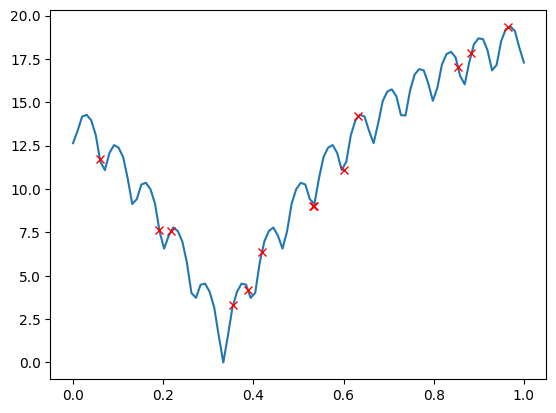

In [ ]:
grid = jnp.linspace(0, 1, 100)
plt.plot(grid, f(grid[..., None]))
plt.plot(model.observed_xs, model.observed_ys, 'rx')
plt.plot(grid, model.predict(grid[..., None]), 'g-')
plt.grid()
plt.show()